In [1]:
%load_ext autoreload
%autoreload 2

import cv2
from ultralytics import YOLO
from pose_estimation import load_model, write_pose_predictions, pred_to_original_size, heatmaps_to_coords, JOINTS_MAP, augment_individual_jsons, augment_coco_keypoints, eval_all_models, hard_argmax_2d
from hand_detection import pad_bb_square
import torchvision.transforms.functional as TF
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset
from seaborn import heatmap
import matplotlib.pyplot as plt
from torch.nn import functional as F
import json
import os

In [2]:
%reload_ext autoreload

In [3]:
def pad_to_simulate_distance(image, pad_percent=0.3):
    h, w, _ = image.shape
    pad_h = int(h * pad_percent)
    pad_w = int(w * pad_percent)
    
    # Add borders around the close-up image
    padded_img = cv2.copyMakeBorder(
        image, pad_h, pad_h, pad_w, pad_w, 
        borderType=cv2.BORDER_CONSTANT, value=[255, 255, 255] # Black background
    )
    return padded_img

In [4]:
def expand_bbox_for_wrist(bbox, img_shape, extension_factor=0.40):
    """
    Expands the bottom/wrist area of the crop more aggressively 
    to capture the forearm context.
    """
    img_h, img_w = img_shape[:2]
    xmin, ymin, xmax, ymax = bbox
    
    h = ymax - ymin
    
    # 1. Expand width slightly to keep aspect ratio stable
    pad_w = (xmax - xmin) * 0.15
    new_xmin = max(0, int(xmin - pad_w))
    new_xmax = min(img_w, int(xmax + pad_w))
    
    # 2. Expand the top slightly (10%)
    new_ymin = max(0, int(ymin - (h * 0.10)))
    
    # 3. Push the BOTTOM down aggressively (40%) to grab the wrist/forearm
    new_ymax = min(img_h, int(ymax + (h * extension_factor)))
    
    return torch.Tensor([new_xmin, new_ymin, new_xmax, new_ymax])

In [5]:
pose_est_model = load_model('./pose_estimation/models/best.pt')
hand_det_model = YOLO('./hand_detection/runs/detect/train/weights/best.pt')
joints_map=JOINTS_MAP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
frame = cv2.imread('./pose_estimation/test_samples/WIN_20260708_20_07_39_Pro.jpg')
pose_in_sz = (pose_est_model.img_size, pose_est_model.img_size)
results = hand_det_model.predict(frame, verbose=False)
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
for r in results:
    boxes = r.boxes
    for box in boxes:
        # Get box coordinates in (left, top, right, bottom) format
        b = box.xyxy[0]
        center_x, center_y, __, __ = box.xywh[0]
        b = expand_bbox_for_wrist(b, frame.shape, 0.40)
        hand_image, coords = pad_bb_square(frame, b)
        # hand_image = pad_to_simulate_distance(hand_image, pad_percent=0.2)
        input_image = TF.to_tensor(cv2.resize(hand_image, pose_in_sz))
        normalization = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
        normalized_input_image = normalization(input_image)
        normalized_input_image = normalized_input_image.to(device).unsqueeze(0)
        with torch.no_grad():
            heatmaps = pose_est_model(normalized_input_image)
            # joints = joints[0, :, :, :]
        B, C, H, W = heatmaps.shape
        input_image = input_image.squeeze(0)
        print("Max logit value:", heatmaps.max().item())
        print("Min logit value:", heatmaps.min().item())
        # joints = _soft_argmax_2d(heatmaps, temperature=0.1)
        joints = hard_argmax_2d(heatmaps)
        print(joints.shape)
        joints = joints[0]*224
        joints = joints.to('cpu')
        print(joints)
        input_image = (input_image.permute(1, 2, 0).cpu().numpy() * 255).astype('uint8')
        input_image = cv2.cvtColor(input_image, cv2.COLOR_RGB2BGR)
        pose_image = write_pose_predictions(input_image, joints, joints_map, 1, 1)
        cv2.imwrite('./test3.png', pose_image)
        corrected_joints = pred_to_original_size(coords[2]-coords[0], pose_est_model.img_size, joints)
        shift = torch.Tensor([[center_x, center_y]]) # JUst not correct
        corrected_joints = corrected_joints + shift
        frame = write_pose_predictions(frame, corrected_joints, joints_map, 4, 5)
        conf = float(box.conf[0])
        label = f"{hand_det_model.names[0]} {conf:.2f}"
        # annotator.box_label(b, label)
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    # frame = annotator.result()
cv2.imwrite('./pose_test1.png', frame)

Max logit value: 0.49634218215942383
Min logit value: -0.01696198247373104
torch.Size([1, 21, 2])
tensor([[ 81.4545, 154.7636],
        [134.4000, 122.1818],
        [138.4727, 114.0364],
        [142.5455, 105.8909],
        [146.6182,  89.6000],
        [118.1091,  89.6000],
        [126.2545,  65.1636],
        [130.3273,  61.0909],
        [105.8909,  85.5273],
        [109.9636,  40.7273],
        [109.9636,  57.0182],
        [109.9636,  65.1636],
        [105.8909,  77.3818],
        [ 93.6727,  85.5273],
        [134.4000, 118.1091],
        [ 93.6727,  44.8000],
        [142.5455, 101.8182],
        [134.4000, 118.1091],
        [134.4000, 114.0364],
        [138.4727, 109.9636],
        [ 69.2364,  52.9455]])


True

In [32]:
# Wrist heatmap [H, W]
wrist_map = heatmaps[0, 0] # Batch 0, Joint 0 (Wrist)

# Hard Argmax (Exact peak pixel location)
max_idx = torch.argmax(wrist_map)
hard_y = (max_idx // W).item() * (224 / H)
hard_x = (max_idx % W).item() * (224 / W)

# Soft Argmax location
soft_x = joints[0, 0].item()
soft_y = joints[0, 1].item()

print(f"Wrist Hard Argmax (Peak Pixel): X={hard_x:.1f}, Y={hard_y:.1f}")
print(f"Wrist Soft Argmax (Center of Mass): X={soft_x:.1f}, Y={soft_y:.1f}")

Wrist Hard Argmax (Peak Pixel): X=80.0, Y=156.0
Wrist Soft Argmax (Center of Mass): X=81.5, Y=158.8


In [2]:
def hard_argmax_2d(heatmaps):
    """
    Extracts exact peak (x, y) coordinates in normalized [0, 1] range.
    """
    B, C, H, W = heatmaps.shape
    heatmaps_flat = heatmaps.view(B, C, -1)
    max_indices = torch.argmax(heatmaps_flat, dim=-1)
    
    pred_y = (max_indices // W).float() / (H - 1)
    pred_x = (max_indices % W).float() / (W - 1)
    
    return torch.stack([pred_x, pred_y], dim=-1)

In [7]:
import json
import os

def filter_coco_json(original_json_path, subset_images_dir, output_json_path):
    # 1. Get the list of filenames you actually kept in your directory
    kept_filenames = set(os.listdir(subset_images_dir))
    
    with open(original_json_path, 'r') as f:
        coco_data = json.load(f)

    # 2. Filter the 'images' list and track the valid image IDs
    new_images = []
    kept_image_ids = set()
    
    for img in coco_data['images']:
        if img['file_name'] in kept_filenames:
            new_images.append(img)
            kept_image_ids.add(img['id'])
            
    # 3. Filter the 'annotations' list based on our kept image IDs
    new_annotations = [
        ann for ann in coco_data['annotations'] 
        if ann['image_id'] in kept_image_ids
    ]
    
    # 4. Construct the new subset COCO dictionary
    subset_coco = {
        "info": coco_data.get("info", {}),
        "licenses": coco_data.get("licenses", []),
        "categories": coco_data["categories"], # Keep all classes intact
        "images": new_images,
        "annotations": new_annotations
    }
    
    # 5. Save out the clean JSON file
    with open(output_json_path, 'w') as f:
        json.dump(subset_coco, f, indent=4)
        
    print(f"Done! Saved {len(new_images)} images and {len(new_annotations)} annotations.")

# Example usage:
filter_coco_json(
    original_json_path="./merged_dataset/hand_keypoints/train/_annotations.coco.json",
    subset_images_dir="./merged_dataset/hand_keypoints/train/images",
    output_json_path="./merged_dataset/hand_keypoints/train/annotations.json"
)

Done! Saved 8631 images and 8631 annotations.


In [ ]:
cmu_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((224,224), antialias=True)])
train_data = CMUSyntheticHandDataset(img_dir='./merged_dataset/CMUSyntheticHands/train/images',
                                    json_dir='./merged_dataset/CMUSyntheticHands/train/labels',
                                    transform=cmu_transform,
                                    heatmaps=False)
train_dl = DataLoader(train_data, batch_size=48, shuffle=True, num_workers=3, pin_memory=False, persistent_workers=False)

torch.Size([48, 3, 224, 224])
torch.Size([48, 21, 3])
torch.Size([21, 2])
(224, 224, 3)


In [18]:
train_images, train_labels = next(iter(train_dl))
print(train_images.size())
print(train_labels.size())
train_image = train_images[0, :, :, :]
train_label = train_labels[0, :, :2]
train_label = torch.flip(train_label, dims=[1])
print(train_label.size())

processed = write_pose_predictions(train_image, train_label, JOINTS_MAP, 3, 3)
cv2.imwrite('./test4.png', processed)
print(processed.shape)

torch.Size([48, 3, 224, 224])
torch.Size([48, 21, 3])
torch.Size([21, 2])
(224, 224, 3)


In [ ]:
frame = cv2.imread('./pose_estimation/test_samples/00000000.jpg')
pose_in_sz = (pose_est_model.img_size, pose_est_model.img_size)
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
# Get box coordinates in (left, top, right, bottom) format
input_image = TF.to_tensor(cv2.resize(frame, pose_in_sz))
normalization = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
normalized_input_image = normalization(input_image)
normalized_input_image = normalized_input_image.to(device).unsqueeze(0)
with torch.no_grad():
    joints = pose_est_model(normalized_input_image)
    joints = joints[0, :, :, :]/0.1
input_image = input_image.squeeze(0)
heatmaps = F.softmax(joints)
joints = heatmaps_to_coords(joints)*4

print(joints)
pose_image = write_pose_predictions(input_image, joints, joints_map, 2, 2)
cv2.imwrite('./test3.png', pose_image)
print('here')

tensor([[124.,  76.],
        [108.,  88.],
        [ 96.,  84.],
        [ 88.,  92.],
        [ 76.,  96.],
        [108., 112.],
        [108., 128.],
        [108., 140.],
        [104., 148.],
        [124., 124.],
        [124., 140.],
        [124., 148.],
        [128., 156.],
        [132., 120.],
        [140., 136.],
        [140., 140.],
        [140., 148.],
        [140., 120.],
        [144., 128.],
        [148., 132.],
        [144., 140.]])
here


C:\Users\maxwe\AppData\Local\Temp\ipykernel_18756\4034589281.py:15: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  heatmaps = F.softmax(joints)


torch.Size([1, 21, 56, 56])


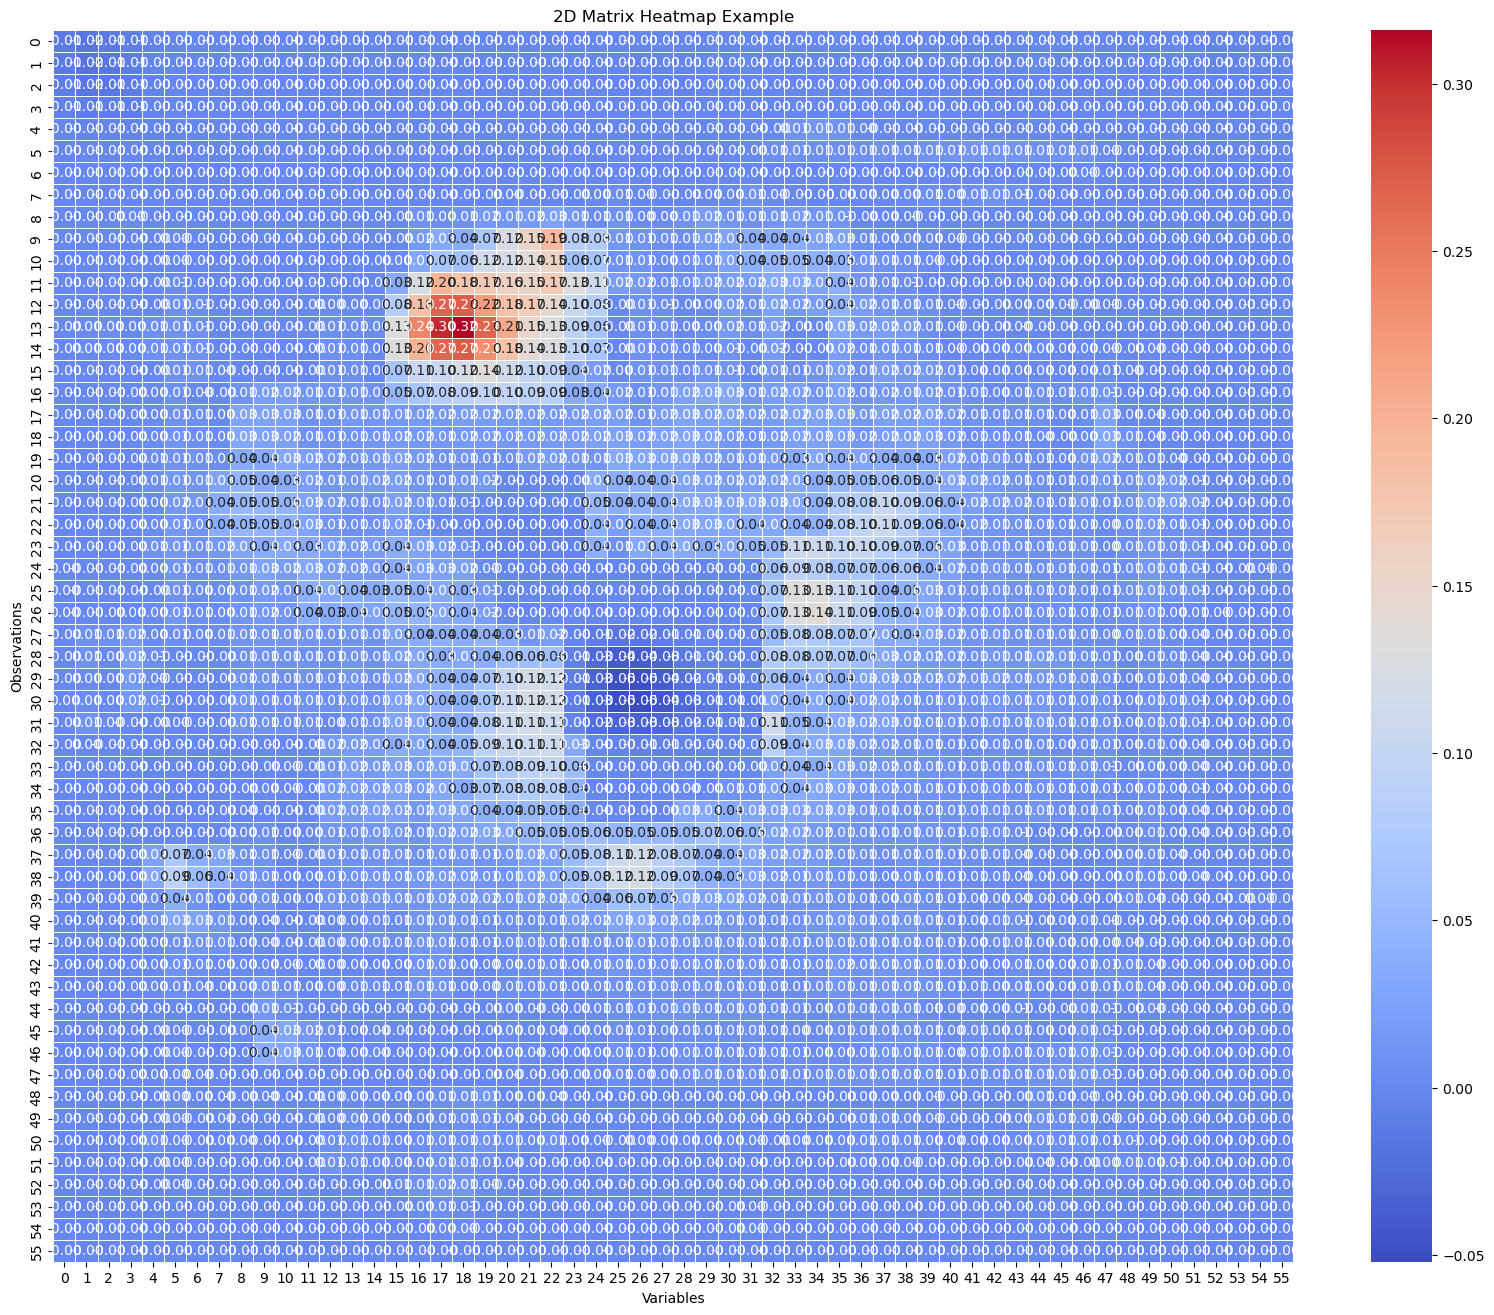

In [45]:
heatmaps = heatmaps.to('cpu')
plt.figure(figsize=(20, 16))
print(heatmaps.shape)
target = heatmaps.view((21, 56, 56))[20]
heatmap(
    target,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'magma', 'Blues')
    linewidths=0.5,  # Add lines between cells
)
# 3. Add titles and show
plt.title("2D Matrix Heatmap Example")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

torch.Size([1, 21, 56, 56])


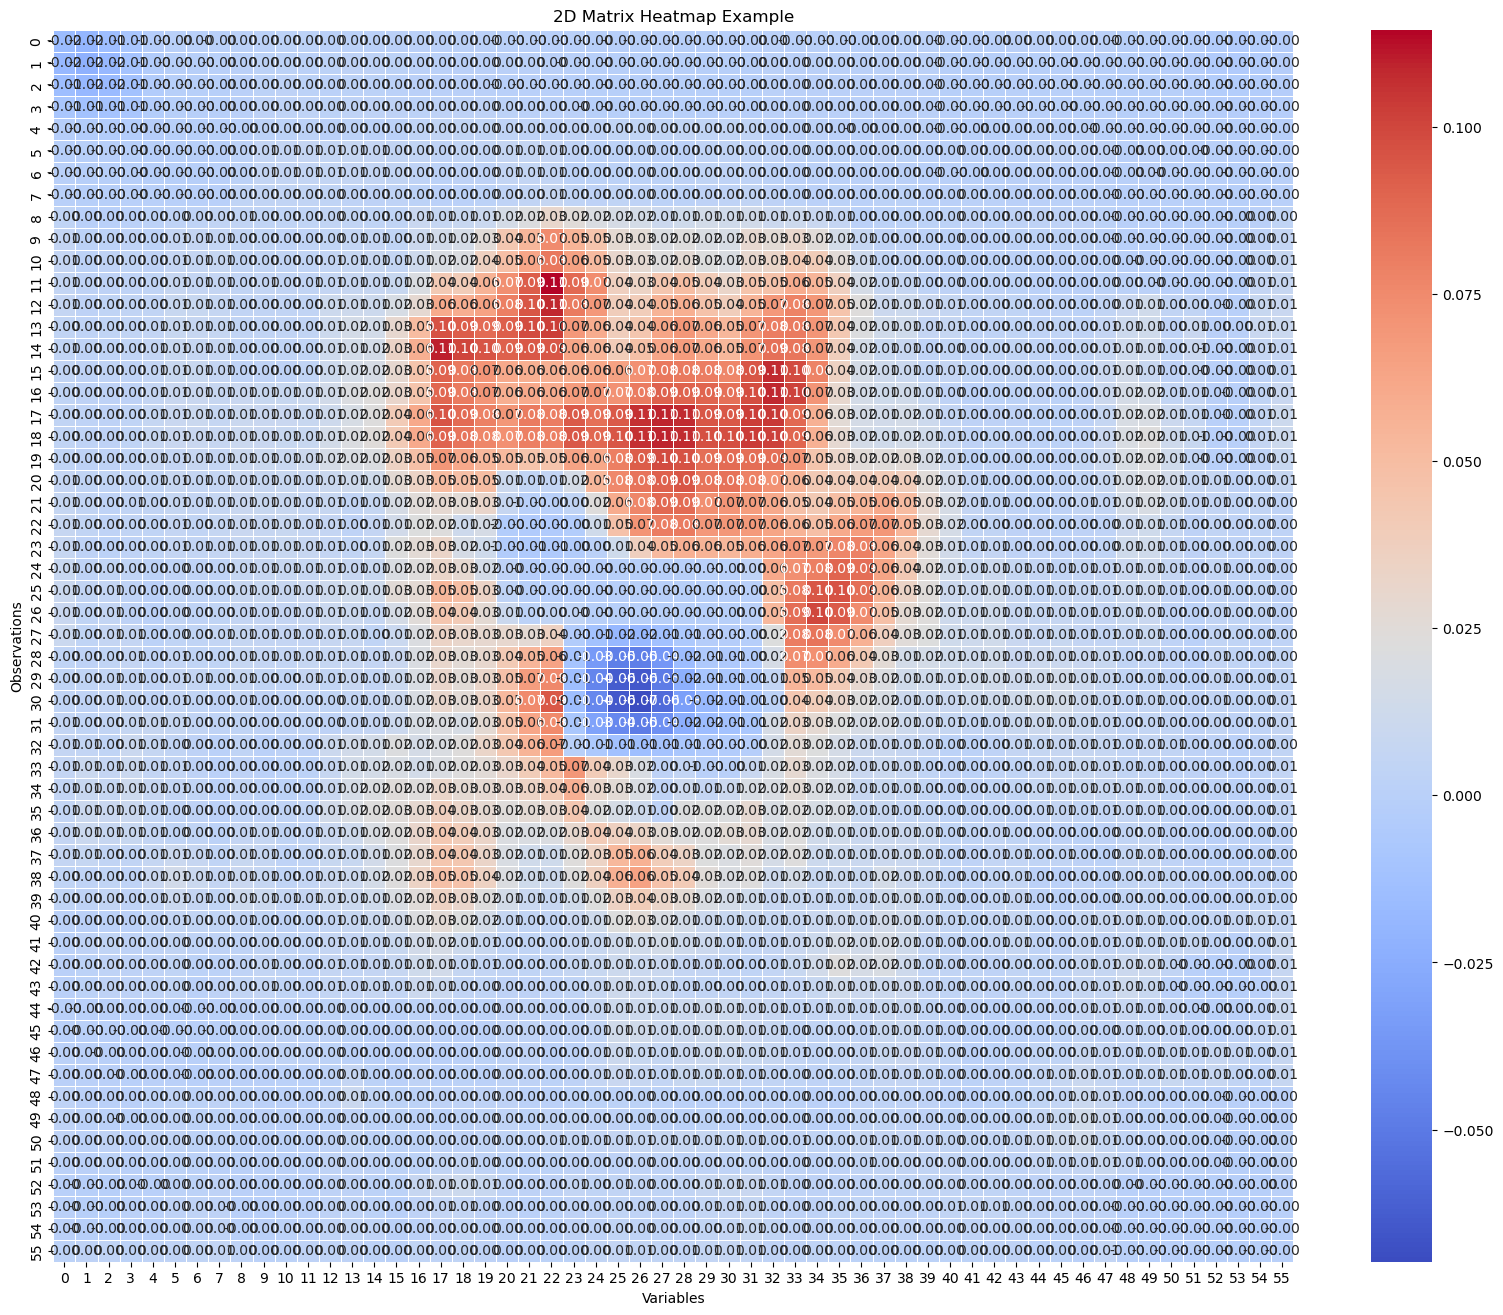

In [46]:
heatmaps = heatmaps.to('cpu')
plt.figure(figsize=(20, 16))
print(heatmaps.shape)
target = torch.sum(heatmaps.view((21, 56, 56)), keepdim=True, dim=0).view((56, 56))/21
heatmap(
    target,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'magma', 'Blues')
    linewidths=0.5,  # Add lines between cells
)
# 3. Add titles and show
plt.title("2D Matrix Heatmap Example")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

In [ ]:
evaluate_batch('./pose_estimation/models', './merged_dataset/hand_keypoints/val/images', './merged_dataset/hand_keypoints/val/annotations.json', batch_size=48, total_models=65)

loading annotations into memory...
Done (t=0.17s)
creating index...
index created!
Hand Keypoints Validation Set Loaded.


7it [00:03,  2.22it/s]


KeyboardInterrupt: 

In [10]:
augment_coco_keypoints('./merged_dataset/hand_keypoints/val/annotations.json', './merged_dataset/hand_keypoints/val/images',
                        './merged_dataset/hand_keypoints_augmented/val/images', './merged_dataset/hand_keypoints_augmented/val/annotations.json')


In [11]:
augment_individual_jsons('./merged_dataset/CMUSyntheticHands/val/images', './merged_dataset/CMUSyntheticHands/val/labels',
                        './merged_dataset/CMUSyntheticHands_aug/val/images', './merged_dataset/CMUSyntheticHands_aug/val/labels')

In [112]:
cmu_transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((224,224), antialias=True)])
val_data = CMUSyntheticHandDataset(img_dir='./merged_dataset/CMUSyntheticHands/val/images',
                                        json_dir='./merged_dataset/CMUSyntheticHands/val/labels',
                                        transform=cmu_transform,
                                        heatmaps=True)
val_dl = DataLoader(val_data, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

In [143]:
# Pull a single sample from your training dataset
img_tensor, (gt_coords, target_heatmaps, visibility) = next(iter(val_dl))
img_tensor = img_tensor.squeeze(0)
target_heatmaps = target_heatmaps.squeeze(0)
# Extract GT coordinates from target heatmaps using Hard Argmax
C, H, W = target_heatmaps.shape
flat_gt = target_heatmaps.view(C, H * W)
gt_max_idx = torch.argmax(flat_gt, dim=-1)
gt_y = (gt_max_idx // W).float() * 4.0
gt_x = (gt_max_idx % W).float() * 4.0
gt_coords_224 = torch.stack([gt_x, gt_y], dim=-1)

# Render GT targets directly onto the GT input image
gt_vis = write_pose_predictions(img_tensor, gt_coords_224, JOINTS_MAP)
cv2.imwrite('./debug_ground_truth.png', gt_vis)

True

In [34]:
pose_est_model.eval()

with torch.no_grad():
    # 1. Grab first batch from validation dataloader
    images, (gt_coords, target_heatmaps, visibility) = next(iter(val_dl))
    
    # Take the VERY FIRST image in the batch
    img_tensor = images[0]  # Shape: [3, 224, 224]
    
    # 2. Pass batch through model
    input_batch = images.to(device)  # Shape: [B, 3, 224, 224]
    raw_heatmaps = pose_est_model(input_batch)  # Shape: [B, 21, 56, 56]
    
    # 3. Extract heatmaps for ONLY the first image in batch
    sample_heatmaps = raw_heatmaps[0]  # Shape: [21, 56, 56]
    
    # 4. Hard Argmax prediction on single image tensor
    C, H, W = sample_heatmaps.shape
    flat_heatmaps = sample_heatmaps.view(C, H * W)  # Shape: [21, 3136]
    max_indices = torch.argmax(flat_heatmaps, dim=-1)  # Shape: [21]
    
    # Reconstruct (X, Y) coordinates in 224x224 image space
    pred_y = (max_indices // W).float() * 4.0
    pred_x = (max_indices % W).float() * 4.0
    pred_coords = torch.stack([pred_x, pred_y], dim=-1).cpu()

# 5. Render model prediction on the first image
pred_vis = write_pose_predictions(img_tensor, pred_coords, JOINTS_MAP)
cv2.imwrite('./debug_model_on_dataset0.png', pred_vis)

NameError: name 'pose_est_model' is not defined

In [5]:
frame = cv2.imread('./pose_estimation/test_samples/WIN_20260708_20_07_39_Pro.jpg')
eval_all_models('pose_estimation/models', frame, 'pose_estimation/eval')

In [22]:
import torch
x = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])

torch.linalg.vector_norm(x, dim=1)

tensor([2.2361, 5.0000, 7.8102])

In [11]:
import pyautogui

pyautogui.scroll(100)
pyautogui.hotkey('alt', 'left')
print('fail')

fail


In [32]:
import torch

x = torch.tensor([False, False, False, False])

val = x.sum()
print(val.item())

y = torch.empty(0)
print(y)

0
tensor([])


In [14]:
import cv2
from datetime import datetime
 
# Open the default webcam (0)
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)

diff = datetime.now()
diff = diff - diff

# Check if the webcam was opened successfully
c = 0

retrieve_avg = diff
grab_avg = diff
while cap.isOpened():
    start = datetime.now()
    frame = cap.grab()
    print(frame)
    grabtime = datetime.now()
    ret, frame =cap.retrieve()
    # ret, frame = cap.read()
    end = datetime.now()
    if not ret:
        print('broke')
        break

    diff += end - start
    retrieve_avg += end - grabtime
    grab_avg += grabtime-start
    c += 1
    # Break loop if 'q' key is pressed
    if c == 1000:
        avg = diff/c
        print(avg)
        print(grab_avg/c)
        print(retrieve_avg/c)
        break
cap.release()

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [6]:
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
cap.set(cv2.CAP_PROP_FRAME_WIDTH, config['width'])
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, config['height'])
actual_width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
actual_height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
print(f"Actual Resolution: {actual_width}x{actual_height}")

NameError: name 'config' is not defined

In [12]:
config = {}
config['width'] = 3840
config['height'] = 2160

In [46]:
from pipeline import HandPosePipeline
from datetime import datetime
import cv2

models = HandPosePipeline('./models/hand_detector.engine', './models/pose_estimator.pt', 'cuda')

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.


In [44]:
frame = cv2.imread('./pose_estimation/test_samples/WIN_20260708_20_07_30_Pro.jpg')
diff = datetime.now()
diff = diff - diff
for i in range(100):
    start = datetime.now()
    keypoints, coords = models.process_frame(frame, 0.4)
    end = datetime.now()

    diff += end - start

print(f' average time: {diff/(i+1)}')

2026-08-11 13:36:30.959863
2026-08-11 13:36:30.960887
2026-08-11 13:36:30.982931
2026-08-11 13:36:30.983928
2026-08-11 13:36:31.004900
2026-08-11 13:36:31.004900
2026-08-11 13:36:31.024848
2026-08-11 13:36:31.025983
2026-08-11 13:36:31.044933
2026-08-11 13:36:31.044933
2026-08-11 13:36:31.063981
2026-08-11 13:36:31.066945
2026-08-11 13:36:31.084897
2026-08-11 13:36:31.084897
2026-08-11 13:36:31.103995
2026-08-11 13:36:31.103995
2026-08-11 13:36:31.122456
2026-08-11 13:36:31.124451
2026-08-11 13:36:31.144397
2026-08-11 13:36:31.144397
2026-08-11 13:36:31.162444
2026-08-11 13:36:31.163442
2026-08-11 13:36:31.182393
2026-08-11 13:36:31.183390
2026-08-11 13:36:31.206945
2026-08-11 13:36:31.207942
2026-08-11 13:36:31.227888
2026-08-11 13:36:31.228885
2026-08-11 13:36:31.248948
2026-08-11 13:36:31.249946
2026-08-11 13:36:31.269981
2026-08-11 13:36:31.270978
2026-08-11 13:36:31.291922
2026-08-11 13:36:31.292920
2026-08-11 13:36:31.314861
2026-08-11 13:36:31.316855
2026-08-11 13:36:31.338018
2

In [ ]:
from ultralytics import YOLO

model = YOLO('./models/hand_detector.pt')

model.export(format="engine", quantize='fp16')



WARNING TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.4.86  Python-3.10.20 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 2080, 8192MiB)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'models\hand_detector.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime-gpu', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/17.2 MB ? eta -:--:--
   ---------- ----------------------------- 4.7/17.2 MB 23.7 MB/s eta 0:00:01
   ------------------------ --------------- 10.5/17.2 MB 25.2 MB/s eta 0:00:01
   -------------------------------------- - 16.5/17.2 MB 26.7 MB/s eta 0:00:01
   ---------------------------------------

c:\Users\maxwe\.conda\envs\torch_env\lib\site-packages\torch\onnx\symbolic_opset9.py:5385: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: slimming with onnxslim 0.1.95...
ONNX: export success  51.6s, saved as 'models\hand_detector.onnx' (9.3 MB)

TensorRT: starting export with TensorRT 11.2.1.2...
requirements: Ultralytics requirement ['nvidia-modelopt[onnx]>=0.44'] not found, attempting AutoUpdate...
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 17.4 MB/s  0:00:00
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ------------ --------------------------- 5.2/16.4 MB 26.5 MB/s eta 0:00:01
   -

WindowsPath('models/hand_detector.engine')

: 

In [5]:
from pose_estimation import HandJointsDetection, load_model
import torch
# Load your custom model
model = load_model('./models/pose_estimator.pt')
model.eval()

# Create dummy input matching your camera image shape (Batch, Channels, Height, Width)
dummy_input = torch.randn(1, 3, 224, 224, device="cuda")

# Export to ONNX
torch.onnx.export(
    model, 
    dummy_input, 
    "./models/model.onnx", 
    export_params=True,
    opset_version=17,
    input_names=["input"],
    output_names=["output"]
)

W0810 23:40:16.931000 9332 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `HandJointsDetection([...]` with `torch.export.export(..., strict=False)`...


W0810 23:40:19.394000 9332 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `HandJointsDetection([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\maxwe\.conda\envs\torch_env\lib\copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\maxwe\.conda\envs\torch_env\lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "c:\Users\maxwe\.conda\envs\torch_env\lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "c:\Users\maxwe\.conda\envs\torch_env\lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "c:\Users\maxwe\.conda\envs\torch_env\lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: D:\a\onnx\onnx\onnx/version_converter/BaseConverter.h:64: adapter_lookup: Assertion `false` failed: No Adapter To Version $17 for

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.13.0+cu130',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[1,21,56,56]>
            ),
            initializers=(
                %"conv_pool_lyrs.0.bias"<FLOAT,[64]>{Tensor(...)},
                %"conv_pool_lyrs.4.bias"<FLOAT,[64]>{Tensor(...)},
                %"conv_pool_lyrs.7.bias"<FLOAT,[64]>{Tensor(...)},
                %"conv_pool_lyrs.10.res_lyrs.0.bias"<FLOAT,[32]>{Tensor(...)},
                %"conv_pool_lyrs.10.res_lyrs.3.bias"<FLOAT,[32]>{Tensor(...)},
                %"conv_pool_lyrs.10.res_lyrs.6.bias"<FLOAT,[128]>{Tensor(...)},
                %"conv_pool_lyrs.10.skip_lyr.bias"<FLOAT,[128]>{TorchTensor(...

In [1]:
import torch
import torchvision

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

PyTorch Version: 2.13.0+cu130
Torchvision Version: 0.28.0+cu130


In [2]:
import torch
import torchvision

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))
    print("CUDA Compiled Version:", torch.version.cuda)

PyTorch Version: 2.13.0+cu130
CUDA Available: True
Device Name: NVIDIA GeForce RTX 2080
CUDA Compiled Version: 13.0


In [ ]:
import subprocess

cmd = [
    r'C:\TensorRT-Enterprise-11.2.1.2-Windows-amd64-cuda-13.3-Release-external\TensorRT-11.2.1.2\bin\trtexec.exe',
    '--onnx=./models/model.onnx',
    '--saveEngine=model.engine',
    '--fp16',
    '--verbose'
]

try:
    # Capture output to print the actual CUDA/TensorRT error message
    result = subprocess.run(cmd, check=True, capture_output=True, text=True)
    print("Export successful!")
except subprocess.CalledProcessError as e:
    print("--- TRTEXEC ERROR LOG ---")
    print(e.stderr if e.stderr else e.stdout)

--- TRTEXEC ERROR LOG ---
[08/10/2026-23:44:16] [E] Unknown option: --fp16 



In [7]:
from visualize import write_predictions_video
from pose_estimation import JOINTS_MAP, load_model
from ultralytics import YOLO
from tqdm import tqdm

in_video_path = './test_video_2.mp4'

hand_detection = YOLO('./models/hand_detector.engine', task='detect')

for i in tqdm(range(1, 47)):
    pose_est = load_model(f'./pose_estimation/models/{i}.pt')
    out_video_path = f'./test_videos/{i}_2.mp4' 

    write_predictions_video(hand_det_model=hand_detection,
                       pose_est_model=pose_est,
                       joints_map=JOINTS_MAP,
                       in_video_path=in_video_path,
                       out_video_path=out_video_path)

  0%|          | 0/46 [00:00<?, ?it/s]

Loading ./models/hand_detector.engine for TensorRT inference...


 24%|██▍       | 11/46 [03:21<10:41, 18.32s/it]


KeyboardInterrupt: 

In [ ]:
write_predictions_video(hand_det_model=hand_detection,
                       pose_est_model=load_model(f'./pose_estimation/models/best.pt'),
                       joints_map=JOINTS_MAP,
                       in_video_path=in_video_path,
                       out_video_path=f'./test_videos/best_2.mp4')

In [2]:
%reload_ext autoreload

In [1]:
import os
import cv2

# Ensure Windows loads GStreamer DLLs
gstreamer_bin = r"C:\Program Files\gstreamer\1.0\msvc_x86_64\bin"
if os.path.exists(gstreamer_bin):
    os.add_dll_directory(gstreamer_bin)

# Check GStreamer status in OpenCV build info
build_info = cv2.getBuildInformation()
has_gstreamer = "GStreamer:                   YES" in build_info or "GStreamer: NO" not in build_info

print("GStreamer Available in OpenCV:", has_gstreamer)

GStreamer Available in OpenCV: True


In [9]:
import os
gstreamer_bin = r"C:\Program Files\gstreamer\1.0\msvc_x86_64\bin"
if os.path.exists(gstreamer_bin):
    os.add_dll_directory(gstreamer_bin)
    os.environ["PATH"] = gstreamer_bin + os.pathsep + os.environ["PATH"]

import cv2

# Low-latency GStreamer pipeline string for Windows webcams
pipeline = (
    "mfvideosrc ! "
    "image/jpeg,width=1280,height=720,framerate=30/1 ! "
    "jpegdec ! "
    "videoconvert ! "
    "video/x-raw,format=BGR ! "
    "appsink drop=true max-buffers=1 sync=false"
)

cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)

if not cap.isOpened():
    print("Failed to open camera via GStreamer pipeline.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        cv2.imshow("Low-Latency Stream", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Failed to open camera via GStreamer pipeline.


In [1]:
import os
import sys

# 1. Set Debug environment variables BEFORE importing cv2
os.environ["OPENCV_VIDEOIO_DEBUG"] = "1"
os.environ["GST_DEBUG"] = "2"  # Prints GStreamer-level C++ logs

# 2. Add GStreamer DLLs
gstreamer_bin = r"C:\Program Files\gstreamer\1.0\msvc_x86_64\bin"
if os.path.exists(gstreamer_bin):
    os.add_dll_directory(gstreamer_bin)
    os.environ["PATH"] = gstreamer_bin + os.pathsep + os.environ["PATH"]

import cv2

# 3. Print OpenCV's Video I/O build configuration
print("=== OPENCV BUILD INFO ===")
build_info = cv2.getBuildInformation()
for line in build_info.split('\n'):
    print(line)
    # if "Video I/O" in line or "GStreamer" in line:
    #     print(line)
print("=========================")

pipeline = (
    "mfvideosrc ! "
    "image/jpeg,width=1280,height=720,framerate=30/1 ! "
    "jpegdec ! "
    "videoconvert ! "
    "video/x-raw,format=BGR ! "
    "appsink drop=true max-buffers=1 sync=false"
)

cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)
print("Is Opened:", cap.isOpened())

=== OPENCV BUILD INFO ===

General configuration for OpenCV 5.0.0 =====================================
  Version control:               5.0.0

  Platform:
    Timestamp:                   2026-07-01T09:07:32Z
    Host:                        Windows 10.0.20348 AMD64
    CMake:                       4.3.2
    CMake generator:             Visual Studio 17 2022
    CMake build tool:            C:/Program Files/Microsoft Visual Studio/2022/Enterprise/MSBuild/Current/Bin/amd64/MSBuild.exe
    MSVC:                        1944
    Configuration:               Debug Release
    Algorithm Hint:              ALGO_HINT_ACCURATE

  CPU/HW features:
    Baseline:                    SSE SSE2 SSE3
      requested:                 SSE3
    Dispatched code generation:  SSE4_1 SSE4_2 AVX FP16 AVX2 AVX512_SKX
      SSE4_1 (18 files):         + SSSE3 SSE4_1
      SSE4_2 (1 files):          + SSSE3 SSE4_1 POPCNT SSE4_2
      AVX (17 files):            + SSSE3 SSE4_1 POPCNT SSE4_2 AVX
      FP16 (0 files)

In [3]:
from camera_streamer import ThreadedCamera
import time
import cv2

# Usage in your program:
cam = ThreadedCamera(0)
time.sleep(1) # Allow camera initialization
total_time = time.perf_counter()
total_time = total_time - total_time
c = 0
time_btwn_frames = total_time
t3 = time.perf_counter()
while c<1000:
    t0 = time.perf_counter()
    ret, frame = cam.read() # Fetches immediately from RAM buffer
    if ret:
        c += 1
        t2 = time.perf_counter()
        time_btwn_frames += t2 - t3
        t1 = time.perf_counter()
        t3 = time.perf_counter()
        total_time += t1 - t0

cam.release()
print(time_btwn_frames/(c+1))
print(f"Main thread read latency: {(total_time/(c+1)) * 1000:.4f} ms")
cv2.imwrite('./test.png', frame)

0.06648626193994066
Main thread read latency: 0.2350 ms


True